# Modeling Notebook 

## Goal

Train and evaluate a real stroke prediction model using the raw healthcare stroke dataset.

- **Input**: `dataset/healthcare-dataset-stroke-data.csv`
- **Target**: `stroke` (`1` = stroke, `0` = no stroke)
- **Important**: the real dataset is highly imbalanced, so accuracy is reported but not used alone.
- **Main evaluation metrics**: stroke-class F1, stroke-class precision, stroke-class recall, ROC-AUC, PR-AUC, and confusion matrix.

This notebook matches the final leakage-safe workflow: split first, add missing indicators per split, fit preprocessing only inside training/CV pipelines, tune each candidate model with `GridSearchCV`, select using validation metrics only, and evaluate once on the held-out test set.

In [1]:
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, ParameterGrid, StratifiedKFold, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

## 1) Project paths

The original file provided by the user was `healthcare-dataset-stroke-data.xls`, but its content is CSV text. The project-local copy below has the same file hash and is used so the notebook is portable inside the project folder.


In [2]:
PROJECT_ROOT = Path("..").resolve()
DATA_PATH = PROJECT_ROOT / "dataset" / "healthcare-dataset-stroke-data.csv"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {DATA_PATH}")
print(f"Dataset exists: {DATA_PATH.exists()}")


Project root: D:\Depi final project
Dataset path: D:\Depi final project\dataset\healthcare-dataset-stroke-data.csv
Dataset exists: True


## 2) Load raw data

The raw healthcare dataset is kept unchanged here. We do **not** fill missing BMI values before the split.

`bmi_missing` is also added after splitting so the modeling workflow is explicit: every preprocessing step that can affect model training happens after the holdout sets are created.

In [3]:
raw_df = pd.read_csv(DATA_PATH)
raw_df.columns = raw_df.columns.str.strip()

df = raw_df.copy()

TARGET = "stroke"
X = df.drop(columns=[TARGET, "id"])
y = df[TARGET].astype(int)

dataset_summary = pd.DataFrame(
    {
        "rows": [len(df)],
        "columns": [df.shape[1]],
        "stroke_0": [(y == 0).sum()],
        "stroke_1": [(y == 1).sum()],
        "stroke_1_percent": [y.mean() * 100],
        "bmi_missing": [df["bmi"].isna().sum()],
        "duplicate_rows": [raw_df.duplicated().sum()],
    }
)
display(dataset_summary.round(3))

display(raw_df.head())

,rows,columns,stroke_0,stroke_1,stroke_1_percent,bmi_missing,duplicate_rows
0,5110,12,4861,249,4.873,201,0


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 3) Train / validation / test split

The split is stratified and happens before any preprocessing, missing-indicator creation, median imputation, balancing, or model tuning. This prevents leakage and keeps the test set as a real-world imbalanced holdout.

In [4]:
X_train_val_raw, X_test_raw, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_val_raw,
    y_train_val,
    test_size=0.25,
    stratify=y_train_val,
    random_state=RANDOM_STATE,
)


def add_missing_indicators(dataframe):
    # Add missingness indicators after the split, without filling values.
    dataframe = dataframe.copy()
    if "bmi" in dataframe.columns:
        dataframe["bmi_missing"] = dataframe["bmi"].isna().astype(int)
    return dataframe


X_train = add_missing_indicators(X_train_raw)
X_val = add_missing_indicators(X_val_raw)
X_train_val = add_missing_indicators(X_train_val_raw)
X_test = add_missing_indicators(X_test_raw)

split_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "rows": len(y_train),
            "stroke_0": int((y_train == 0).sum()),
            "stroke_1": int((y_train == 1).sum()),
            "stroke_1_percent": y_train.mean() * 100,
            "bmi_missing": int(X_train["bmi"].isna().sum()),
        },
        {
            "split": "validation",
            "rows": len(y_val),
            "stroke_0": int((y_val == 0).sum()),
            "stroke_1": int((y_val == 1).sum()),
            "stroke_1_percent": y_val.mean() * 100,
            "bmi_missing": int(X_val["bmi"].isna().sum()),
        },
        {
            "split": "test",
            "rows": len(y_test),
            "stroke_0": int((y_test == 0).sum()),
            "stroke_1": int((y_test == 1).sum()),
            "stroke_1_percent": y_test.mean() * 100,
            "bmi_missing": int(X_test["bmi"].isna().sum()),
        },
    ]
)

split_summary.to_csv(REPORTS_DIR / "real_stroke_split_summary.csv", index=False)
display(split_summary.round(3))

,split,rows,stroke_0,stroke_1,stroke_1_percent,bmi_missing
0,train,3066,2917,149,4.860,139
1,validation,1022,972,50,4.892,31
2,test,1022,972,50,4.892,31


## 4) Preprocessing pipeline

All preprocessing is fitted only on training data:

- During `GridSearchCV`, the numeric median imputer is fitted separately inside each training fold.
- During validation/test evaluation, the fitted training pipeline is reused without refitting on validation/test rows.
- Numeric features: median imputation + standard scaling.
- Categorical features: most-frequent imputation + one-hot encoding.
- `id` is excluded because it is an identifier, not a clinical feature.

In [5]:
numeric_features = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = [col for col in X_train.columns if col not in numeric_features]

numeric_transformer = SkPipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = SkPipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'bmi_missing']
Categorical features: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


## 5) Helper functions

The final decision threshold is chosen on the validation set by maximizing stroke-class F1. The test set is not used during threshold selection.


In [6]:
def best_f1_threshold(y_true, y_proba):
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    if len(thresholds) == 0:
        return 0.5, 0.0

    scores = 2 * precision[:-1] * recall[:-1] / np.maximum(
        precision[:-1] + recall[:-1],
        1e-12,
    )
    best_idx = int(np.nanargmax(scores))
    return float(thresholds[best_idx]), float(scores[best_idx])


def evaluate_predictions(dataset_name, y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "dataset": dataset_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "positive_f1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "positive_precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "positive_recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "average_precision": average_precision_score(y_true, y_proba),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


## 6) Candidate models and hyperparameter grids

Each candidate model gets its own `GridSearchCV` search space:

- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors
- Support Vector Machine
- Naive Bayes

The search is run on the training split only using stratified cross-validation. Models that support `class_weight` keep balanced class weights because the stroke class is rare.

In [7]:
model_specs = [
    (
        "Logistic Regression",
        LogisticRegression(
            class_weight="balanced",
            max_iter=5000,
            random_state=RANDOM_STATE,
        ),
        {
            "model__C": [0.1, 0.5, 1.0, 2.0],
            "model__solver": ["lbfgs"],
        },
    ),
    (
        "Decision Tree",
        DecisionTreeClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        {
            "model__max_depth": [3, 5, 8, None],
            "model__min_samples_leaf": [1, 5, 10, 20],
            "model__criterion": ["gini", "entropy"],
        },
    ),
    (
        "Random Forest",
        RandomForestClassifier(
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
        {
            "model__n_estimators": [200, 400],
            "model__max_depth": [None, 5, 10],
            "model__min_samples_leaf": [1, 5, 10],
            "model__max_features": ["sqrt", "log2"],
        },
    ),
    (
        "K-Nearest Neighbors",
        KNeighborsClassifier(),
        {
            "model__n_neighbors": [5, 11, 15, 25],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2],
        },
    ),
    (
        "Support Vector Machine",
        SVC(
            kernel="rbf",
            class_weight="balanced",
            probability=True,
            random_state=RANDOM_STATE,
        ),
        {
            "model__C": [0.5, 1.0, 2.0],
            "model__gamma": ["scale", "auto", 0.01],
        },
    ),
    (
        "Naive Bayes",
        GaussianNB(),
        {
            "model__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6],
        },
    ),
]

print(f"Candidate models: {len(model_specs)}")
for model_name, _, param_grid in model_specs:
    print(f"{model_name}: {len(ParameterGrid(param_grid))} grid combinations")

Candidate models: 6
Logistic Regression: 4 grid combinations
Decision Tree: 32 grid combinations
Random Forest: 36 grid combinations
K-Nearest Neighbors: 16 grid combinations
Support Vector Machine: 9 grid combinations
Naive Bayes: 4 grid combinations


## 7) Tune each model, tune threshold on validation, and compare models

For each candidate:

1. `GridSearchCV` tunes model hyperparameters on the training split only.
2. The best estimator from the grid search is used to predict validation probabilities.
3. The classification threshold is tuned on validation data by maximizing stroke-class F1.
4. Test metrics are computed for reporting only; the test set is not used to select hyperparameters or thresholds.

The model ranking uses validation metrics only:

1. Validation ROC-AUC
2. Validation average precision
3. Validation stroke-class F1

In [8]:
tuning_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

model_rows = []
fitted_models = {}

for model_name, model, param_grid in model_specs:
    print(f"Tuning {model_name}...")
    pipeline = SkPipeline(
        steps=[
            ("prep", preprocessor),
            ("model", model),
        ]
    )

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="roc_auc",
        cv=tuning_cv,
        n_jobs=-1,
        refit=True,
        error_score="raise",
    )
    search.fit(X_train, y_train)

    best_pipeline = search.best_estimator_
    val_proba = best_pipeline.predict_proba(X_val)[:, 1]
    threshold, validation_positive_f1 = best_f1_threshold(y_val, val_proba)
    test_proba = best_pipeline.predict_proba(X_test)[:, 1]

    val_metrics = evaluate_predictions("validation", y_val, val_proba, threshold)
    test_metrics = evaluate_predictions("test", y_test, test_proba, threshold)

    model_rows.append(
        {
            "model": model_name,
            "selected_by": "validation_roc_auc_after_grid_search",
            "grid_search_scoring": "roc_auc",
            "best_cv_roc_auc": search.best_score_,
            "best_params": search.best_params_,
            "threshold": threshold,
            "validation_positive_f1_tuned": validation_positive_f1,
            **{f"val_{k}": v for k, v in val_metrics.items() if k not in ["dataset", "threshold"]},
            **{f"test_{k}": v for k, v in test_metrics.items() if k not in ["dataset", "threshold"]},
        }
    )
    fitted_models[model_name] = {
        "pipeline": best_pipeline,
        "threshold": threshold,
        "validation_positive_f1": validation_positive_f1,
        "best_params": search.best_params_,
        "best_cv_roc_auc": search.best_score_,
    }

comparison = pd.DataFrame(model_rows).sort_values(
    ["val_roc_auc", "val_average_precision", "validation_positive_f1_tuned"],
    ascending=False,
)
comparison.to_csv(REPORTS_DIR / "real_stroke_model_comparison.csv", index=False)

display(
    comparison[
        [
            "model",
            "best_cv_roc_auc",
            "threshold",
            "validation_positive_f1_tuned",
            "test_positive_f1",
            "test_positive_precision",
            "test_positive_recall",
            "test_roc_auc",
            "test_average_precision",
            "test_tn",
            "test_fp",
            "test_fn",
            "test_tp",
            "best_params",
        ]
    ].round(4)
)

Tuning Logistic Regression...
Tuning Decision Tree...
Tuning Random Forest...
Tuning K-Nearest Neighbors...
Tuning Support Vector Machine...


C:\Users\georg\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Tuning Naive Bayes...


,model,best_cv_roc_auc,threshold,validation_positive_f1_tuned,test_positive_f1,test_positive_precision,test_positive_recall,test_roc_auc,test_average_precision,test_tn,test_fp,test_fn,test_tp,best_params
4,Support Vector Machine,0.8521,0.1834,0.2883,0.3200,0.2667,0.40,0.8406,0.2855,917,55,30,20,"{'model__C': 0.5, 'model__gamma': 0.01}"
0,Logistic Regression,0.8529,0.7661,0.2857,0.3312,0.2430,0.52,0.8387,0.2375,891,81,24,26,"{'model__C': 0.1, 'model__solver': 'lbfgs'}"
2,Random Forest,0.8486,0.5838,0.2712,0.2963,0.2759,0.32,0.8366,0.2514,930,42,34,16,"{'model__max_depth': None, 'model__max_feature..."
5,Naive Bayes,0.8186,1.0000,0.3077,0.2323,0.1714,0.36,0.7882,0.1613,885,87,32,18,{'model__var_smoothing': 1e-09}
1,Decision Tree,0.8213,0.7723,0.2627,0.2946,0.1897,0.66,0.7933,0.1570,831,141,17,33,"{'model__criterion': 'entropy', 'model__max_de..."
3,K-Nearest Neighbors,0.7940,0.1600,0.2714,0.2639,0.2021,0.38,0.7614,0.1301,897,75,31,19,"{'model__n_neighbors': 25, 'model__p': 2, 'mod..."


## 8) Select the final tuned model

The selected model is the top-ranked validation model after GridSearchCV tuning. The test set has not been used for model selection.

In [9]:
best_name = str(comparison.iloc[0]["model"])
best_bundle = fitted_models[best_name]
best_pipeline = best_bundle["pipeline"]
best_threshold = float(best_bundle["threshold"])
best_params = best_bundle["best_params"]

print(f"Selected model: {best_name}")
print(f"Selected threshold: {best_threshold:.6f}")
print("Selected hyperparameters:")
for param_name, param_value in best_params.items():
    print(f"  {param_name}: {param_value}")

Selected model: Support Vector Machine
Selected threshold: 0.183360
Selected hyperparameters:
  model__C: 0.5
  model__gamma: 0.01


## 9) Final held-out test evaluation

This is the main real-world result. Accuracy is high because most patients did not have a stroke, so the report should emphasize ROC-AUC, recall, precision, F1-score, and the confusion matrix.


In [10]:
val_proba = best_pipeline.predict_proba(X_val)[:, 1]
test_proba = best_pipeline.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_threshold).astype(int)

audit_metrics = pd.DataFrame(
    [
        evaluate_predictions("validation", y_val, val_proba, best_threshold),
        evaluate_predictions("test", y_test, test_proba, best_threshold),
    ]
)
audit_metrics.to_csv(REPORTS_DIR / "real_stroke_best_model_audit.csv", index=False)

final_test_metrics = audit_metrics[audit_metrics["dataset"] == "test"].copy()
final_test_metrics.to_csv(REPORTS_DIR / "model_metrics.csv", index=False)

print("Classification report on held-out test set:")
print(classification_report(y_test, test_pred, digits=4, zero_division=0))

display(audit_metrics.round(4))


Classification report on held-out test set:
              precision    recall  f1-score   support

           0     0.9683    0.9434    0.9557       972
           1     0.2667    0.4000    0.3200        50

    accuracy                         0.9168      1022
   macro avg     0.6175    0.6717    0.6379      1022
weighted avg     0.9340    0.9168    0.9246      1022



,dataset,threshold,accuracy,positive_f1,positive_precision,positive_recall,macro_f1,weighted_f1,roc_auc,average_precision,tn,fp,fn,tp
0,validation,0.1834,0.9227,0.2883,0.2623,0.32,0.6237,0.9263,0.8467,0.2075,927,45,34,16
1,test,0.1834,0.9168,0.3200,0.2667,0.40,0.6379,0.9246,0.8406,0.2855,917,55,30,20


## 10) Confusion matrix, ROC curve, and precision-recall curve


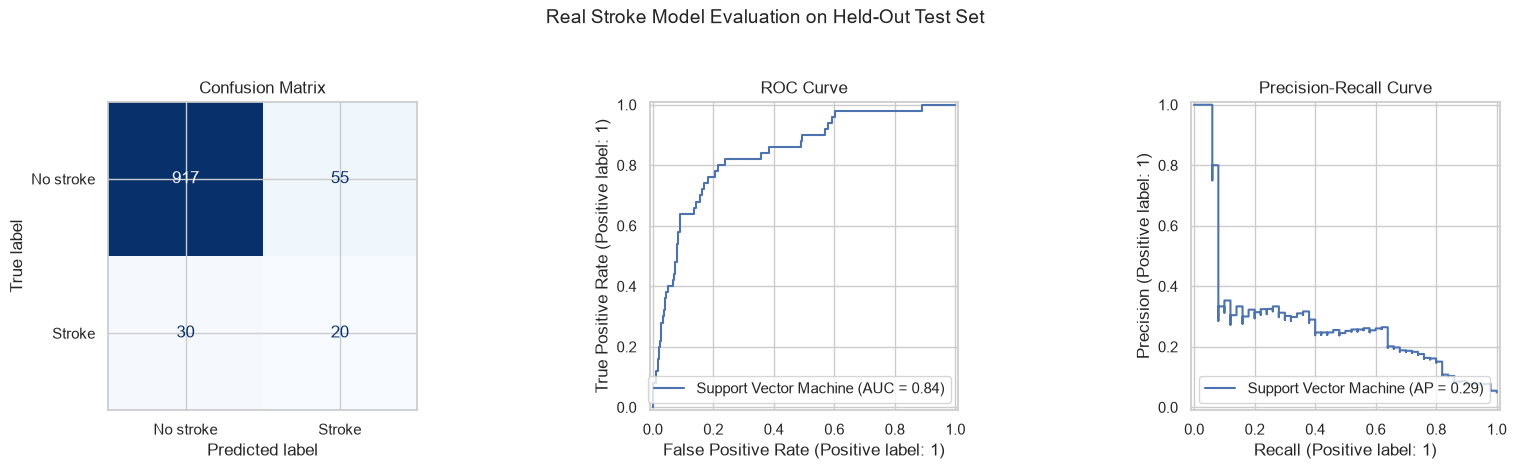

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred,
    display_labels=["No stroke", "Stroke"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(
    y_test,
    test_proba,
    name=best_name,
    ax=axes[1],
)
axes[1].set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(
    y_test,
    test_proba,
    name=best_name,
    ax=axes[2],
)
axes[2].set_title("Precision-Recall Curve")

fig.suptitle("Real Stroke Model Evaluation on Held-Out Test Set", y=1.04, fontsize=14)
fig.tight_layout()
fig.savefig(REPORTS_DIR / "real_stroke_model_evaluation.png", dpi=160, bbox_inches="tight")
fig.savefig(REPORTS_DIR / "confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()


## 11) Save final tuned model and report artifacts

The saved model contains the full preprocessing pipeline, the GridSearchCV-selected model hyperparameters, and the validation-selected threshold.

In [12]:
model_path = MODELS_DIR / "stroke_model_pipeline.joblib"
joblib.dump(
    {
        "pipeline": best_pipeline,
        "threshold": best_threshold,
        "features": X_train.columns.tolist(),
        "target": TARGET,
        "source_file": str(DATA_PATH),
        "best_params": best_params,
        "grid_search_scoring": "roc_auc",
        "selection_metric": "validation ROC-AUC after GridSearchCV; threshold tuned by validation positive-class F1",
    },
    model_path,
)

report_path = REPORTS_DIR / "real_stroke_model_report.txt"
with report_path.open("w", encoding="utf-8") as f:
    f.write("Real Stroke Model Report\n")
    f.write("========================\n\n")
    f.write(f"Source file: {DATA_PATH}\n")
    f.write("Target: stroke\n")
    f.write("Dropped from features: id\n")
    f.write("Missing BMI handling: bmi_missing added after splitting; median imputation fitted inside training/CV pipelines only\n")
    f.write("Split: 60% train / 20% validation / 20% untouched test, stratified\n")
    f.write("Hyperparameter tuning: GridSearchCV per model on the training split, scoring=ROC-AUC\n")
    f.write("Model selection: best validation ROC-AUC after tuning\n")
    f.write("Threshold selection: best validation positive-class F1\n\n")
    f.write("Split summary\n")
    f.write(split_summary.to_string(index=False))
    f.write("\n\n")
    f.write(f"Selected model: {best_name}\n")
    f.write(f"Selected threshold: {best_threshold:.6f}\n")
    f.write("Selected hyperparameters\n")
    for param_name, param_value in best_params.items():
        f.write(f"- {param_name}: {param_value}\n")
    f.write("\n")
    f.write("Best model audit\n")
    f.write(audit_metrics.round(4).to_string(index=False))
    f.write("\n\n")
    f.write("Test classification report\n")
    f.write(classification_report(y_test, test_pred, digits=4, zero_division=0))
    f.write("\n\n")
    f.write("Confusion matrix labels [[TN, FP], [FN, TP]]\n")
    f.write(str(confusion_matrix(y_test, test_pred, labels=[0, 1])))
    f.write("\n")

print(f"Saved model: {model_path}")
print(f"Saved metrics: {REPORTS_DIR / 'model_metrics.csv'}")
print(f"Saved comparison: {REPORTS_DIR / 'real_stroke_model_comparison.csv'}")
print(f"Saved audit: {REPORTS_DIR / 'real_stroke_best_model_audit.csv'}")
print(f"Saved report: {report_path}")
print(f"Saved evaluation plot: {REPORTS_DIR / 'real_stroke_model_evaluation.png'}")

Saved model: D:\Depi final project\models\stroke_model_pipeline.joblib
Saved metrics: D:\Depi final project\reports\model_metrics.csv
Saved comparison: D:\Depi final project\reports\real_stroke_model_comparison.csv
Saved audit: D:\Depi final project\reports\real_stroke_best_model_audit.csv
Saved report: D:\Depi final project\reports\real_stroke_model_report.txt
Saved evaluation plot: D:\Depi final project\reports\real_stroke_model_evaluation.png


## 12) What to say in the report

Use the real held-out test results as the main model result:

- **Accuracy**: high, but secondary because the dataset is imbalanced.
- **ROC-AUC**: useful for showing that the model ranks stroke risk reasonably well.
- **Stroke recall, precision, and F1-score**: most honest for judging stroke detection.
- **Confusion matrix**: required to show how many stroke cases were detected and missed.

Recommended wording:

> Although the model achieved high overall accuracy, the dataset is highly imbalanced, with far fewer stroke cases than non-stroke cases. Therefore, accuracy alone is not enough to evaluate stroke detection. The final evaluation emphasizes stroke-class precision, recall, F1-score, ROC-AUC, and the confusion matrix.
